In [ ]:
"""
## Cell 1: Install Dependencies
"""

# Install required packages
!pip install -q torch transformers accelerate peft
!pip install -q langgraph langchain-core langchain-chroma chromadb
!pip install -q pandas pydantic requests

print("✓ Dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 7.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.3 MB/s

In [ ]:
## Cell 2: Mount Google Drive (for LoRA weights)

from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted")

Mounted at /content/drive
✓ Google Drive mounted


In [ ]:
"""
## Cell 3: Download Chinook Database
"""

import requests
import pathlib

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"

local_path = pathlib.Path("Chinook.db")

if local_path.exists():
    print(f"✓ {local_path} already exists")
else:
    response = requests.get(url)
    if response.status_code == 200:
        local_path.write_bytes(response.content)
        print(f"✓ Downloaded Chinook.db")
    else:
        raise RuntimeError(f"Failed to download: {response.status_code}")

✓ Downloaded Chinook.db


In [ ]:
## Cell 4: Generate Schema CSV Files

import sqlite3
import csv

conn = sqlite3.connect("Chinook.db")
conn.row_factory = sqlite3.Row
cur = conn.cursor()

# Get tables
cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
tables = [row["name"] for row in cur.fetchall()]
print(f"Tables: {tables}")

# Schema cards
with open("schema_cards.csv", "w", newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["table_name", "column_name", "data_type", "is_primary_key", "foreign_key_reference", "sample_value"])

    for table in tables:
        cur.execute(f"PRAGMA table_info('{table}');")
        cols = cur.fetchall()
        cur.execute(f"PRAGMA foreign_key_list('{table}');")
        fks = cur.fetchall()
        fk_map = {fk["from"]: f"{fk['table']}({fk['to']})" for fk in fks}

        for col in cols:
            col_name = col["name"]
            try:
                cur.execute(f"SELECT [{col_name}] FROM [{table}] WHERE [{col_name}] IS NOT NULL LIMIT 1;")
                sample = cur.fetchone()
                sample_val = sample[0] if sample else ""
            except:
                sample_val = ""
            writer.writerow([table, col_name, col["type"], bool(col["pk"]), fk_map.get(col_name, ""), sample_val])

print("✓ Generated schema_cards.csv")

# Glossary
with open("glossary.csv", "w", newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["term", "definition", "example_usage"])
    for table in tables:
        writer.writerow([table, f"Table containing {table} data", f"SELECT * FROM {table}"])
    business_terms = [
        ("Track", "A single song or audio recording", "SELECT Name FROM Track WHERE AlbumId = 1"),
        ("Album", "A collection of tracks released together", "SELECT Title FROM Album WHERE ArtistId = 1"),
        ("Artist", "A musician or band", "SELECT Name FROM Artist WHERE Name LIKE '%AC/DC%'"),
        ("Genre", "Music category like Rock, Jazz, Pop", "SELECT Name FROM Genre"),
        ("Invoice", "A sales transaction record", "SELECT Total FROM Invoice WHERE CustomerId = 1"),
        ("Total Sales", "Sum of Invoice.Total for revenue calculations", "SELECT SUM(Total) FROM Invoice"),
    ]
    for term, definition, example in business_terms:
        writer.writerow([term, definition, example])

print("✓ Generated glossary.csv")

# Query cookbook
with open("query_cookbook.csv", "w", newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["query_id", "description", "sql_query", "dialect", "verified"])
    cookbook_queries = [
        ("Q001", "Total sales by country", "SELECT BillingCountry, SUM(Total) AS TotalSales FROM Invoice GROUP BY BillingCountry ORDER BY TotalSales DESC;", "SQLite", "TRUE"),
        ("Q002", "Top genres by units sold", "SELECT g.Name AS Genre, COUNT(il.InvoiceLineId) AS UnitsSold FROM InvoiceLine il JOIN Track t ON il.TrackId = t.TrackId JOIN Genre g ON t.GenreId = g.GenreId GROUP BY g.Name ORDER BY UnitsSold DESC LIMIT 10;", "SQLite", "TRUE"),
        ("Q003", "Tracks by a specific artist", "SELECT t.Name AS TrackName, al.Title AS Album FROM Track t JOIN Album al ON t.AlbumId = al.AlbumId JOIN Artist ar ON al.ArtistId = ar.ArtistId WHERE ar.Name = 'AC/DC';", "SQLite", "TRUE"),
        ("Q004", "Average track length by genre", "SELECT g.Name AS Genre, AVG(t.Milliseconds)/1000.0 AS AvgSeconds FROM Track t JOIN Genre g ON t.GenreId = g.GenreId GROUP BY g.Name ORDER BY AvgSeconds DESC;", "SQLite", "TRUE"),
    ]
    for row in cookbook_queries:
        writer.writerow(row)

print("✓ Generated query_cookbook.csv")
conn.close()

Tables: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']
✓ Generated schema_cards.csv
✓ Generated glossary.csv
✓ Generated query_cookbook.csv


In [ ]:
"""
## Cell 5: Initialize ChromaDB Vector Store
"""

# %%
import pandas as pd
from chromadb.utils import embedding_functions
import chromadb

# Create documents
docs = []

# Schema cards
schema_df = pd.read_csv("schema_cards.csv")
for _, row in schema_df.iterrows():
    content = f"Table: {row['table_name']}\nColumn: {row['column_name']}\nData type: {row['data_type']}\nIs PK: {row['is_primary_key']}\nFK ref: {row['foreign_key_reference']}\nSample: {row['sample_value']}"
    docs.append({"content": content, "metadata": {"source": "schema", "table": row["table_name"]}})

# Glossary
glossary_df = pd.read_csv("glossary.csv")
for _, row in glossary_df.iterrows():
    content = f"Term: {row['term']}\nDefinition: {row['definition']}\nExample: {row['example_usage']}"
    docs.append({"content": content, "metadata": {"source": "glossary", "term": row["term"]}})

# Cookbook
cookbook_df = pd.read_csv("query_cookbook.csv")
for _, row in cookbook_df.iterrows():
    content = f"Query: {row['description']}\nSQL: {row['sql_query']}"
    docs.append({"content": content, "metadata": {"source": "cookbook", "query_id": row["query_id"]}})

# Create ChromaDB with default embeddings
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(
    name="chinook_schema",
    embedding_function=embedding_functions.DefaultEmbeddingFunction()
)

# Add documents
collection.add(
    documents=[d["content"] for d in docs],
    metadatas=[d["metadata"] for d in docs],
    ids=[f"doc_{i}" for i in range(len(docs))]
)

print(f"✓ Indexed {len(docs)} documents into ChromaDB")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:07<00:00, 10.6MiB/s]


✓ Indexed 85 documents into ChromaDB


In [ ]:
"""
## Cell 6: Load Qwen Models (Base + Fine-tuned for Synthesizer)
"""

# %%
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-Coder-7B-Instruct"

# Path to fine-tuned LoRA adapter for SQL synthesis
# Set to None to use base model for everything
SYNTHESIZER_LORA_PATH = "/content/drive/MyDrive/d266/project/SQL_Synthesizer_Weights_v4"  # <-- Your fine-tuned adapter on Google Drive

print(f"Loading {MODEL_NAME}...")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Load tokenizer (shared)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load BASE model (for Planner and Controller)
print("Loading base model for Planner/Controller...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
base_model.eval()
print("✓ Base model loaded")


# Load FINE-TUNED model (for Synthesizer)

if SYNTHESIZER_LORA_PATH:
    print(f"Loading fine-tuned model with LoRA adapter from {SYNTHESIZER_LORA_PATH}...")
    synthesizer_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    synthesizer_model = PeftModel.from_pretrained(synthesizer_model, SYNTHESIZER_LORA_PATH)
    synthesizer_model = synthesizer_model.merge_and_unload()  # Merge for faster inference
    synthesizer_model.eval()
    print("✓ Fine-tuned synthesizer model loaded")
else:
    # Use base model for synthesizer too
    synthesizer_model = base_model
    print("✓ Using base model for synthesizer (no LoRA adapter specified)")

Loading Qwen/Qwen2.5-Coder-7B-Instruct...
GPU Available: True
GPU: NVIDIA A100-SXM4-80GB


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ Base model loaded
Loading fine-tuned model with LoRA adapter from /content/drive/MyDrive/d266/project/SQL_Synthesizer_Weights_v4...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✓ Fine-tuned synthesizer model loaded


In [ ]:
"""
## Cell 7: Define State and Pydantic Models (from sql_agent/utils/state.py)
"""

from typing import TypedDict, Literal, Optional, List, Any
from pydantic import BaseModel, Field

# Pydantic Models for Structured LLM Output

class QueryPlan(BaseModel):
    """Structured output from the Planner agent."""
    primary_entity: str = Field(description="Main table/entity the user is asking about")
    tables_involved: List[str] = Field(description="All tables needed for the query")
    join_path: str = Field(description="How tables connect, e.g., 'Track -> Album -> Artist'")
    filters: List[str] = Field(description="Filter conditions, e.g., ['Artist.Name = AC/DC']")
    aggregations: Optional[str] = Field(default=None, description="Aggregation needed, e.g., 'COUNT', 'SUM'")
    ordering: Optional[str] = Field(default=None, description="ORDER BY clause if needed")
    limit: Optional[int] = Field(default=50, description="Result limit")
    reasoning: str = Field(description="Explanation of why this plan was chosen")


class ClarificationRequest(BaseModel):
    """Returned when the Planner needs user clarification."""
    ambiguous_term: str = Field(description="The term that is unclear")
    possible_interpretations: List[str] = Field(description="Possible meanings")
    question: str = Field(description="Question to ask the user")


class ExecutionResult(BaseModel):
    """Result from the Executor."""
    success: bool
    columns: Optional[List[str]] = None
    data: Optional[List[Any]] = None
    row_count: int = 0
    total_row_count: int = 0
    truncated: bool = False
    error_message: Optional[str] = None
    error_type: Optional[Literal["syntax", "logic", "security", "timeout"]] = None


# Shared Agent State

class AgentState(TypedDict):
    """Shared state across all agents in the pipeline."""
    user_question: str
    schema_context: Optional[str]
    glossary_context: Optional[str]
    cookbook_context: Optional[str]
    query_plan: Optional[dict]
    needs_clarification: bool
    clarification_request: Optional[dict]
    resolved_values: Optional[dict]
    current_date: str
    generated_sql: Optional[str]
    execution_result: Optional[dict]
    retry_count: int
    max_retries: int
    error_feedback: Optional[str]
    final_answer: Optional[str]
    status: Literal["planning", "synthesizing", "executing", "validating", "complete", "failed", "clarifying"]

print("✓ State and Pydantic models defined")

✓ State and Pydantic models defined


In [ ]:
"""
## Cell 8: Define Model Wrapper (from sql_agent/utils/models.py)
"""

# %%
import json
import re

class QwenResponse:
    """Response object mimicking LangChain message format."""
    def __init__(self, content: str):
        self.content = content


class QwenModel:
    """Wrapper for Qwen model with chat interface."""

    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    def invoke(self, prompt: str, max_new_tokens: int = 1024) -> QwenResponse:
        """Generate response for a prompt (LangChain-compatible interface)."""
        messages = [
            {"role": "system", "content": "You are a helpful SQL assistant."},
            {"role": "user", "content": prompt}
        ]

        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            generated_ids = self.model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=self.tokenizer.eos_token_id
            )

        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]

        response = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        return QwenResponse(content=response)

    def with_structured_output(self, schema):
        """Return a wrapper that parses output into a Pydantic model."""
        return StructuredQwenModel(self, schema)


class StructuredQwenModel:
    """Wrapper for structured output parsing."""

    def __init__(self, model: QwenModel, schema):
        self.model = model
        self.schema = schema

    def invoke(self, prompt: str):
        """Generate and parse structured output."""
        # Create a clearer prompt with an example
        structured_prompt = f"""{prompt}

You must respond with a JSON object with these exact fields:
- "primary_entity": string (the main table name)
- "tables_involved": array of strings (list of table names)
- "join_path": string (how tables connect, e.g., "Track -> Album -> Artist" or "None")
- "filters": array of strings (filter conditions, can be empty [])
- "aggregations": string or null (e.g., "COUNT", "SUM", or null)
- "ordering": string or null (e.g., "DESC" or null)
- "limit": integer (default 50)
- "reasoning": string (brief explanation)

Example response format:
{{"primary_entity": "Track", "tables_involved": ["Track"], "join_path": "None", "filters": [], "aggregations": "COUNT", "ordering": null, "limit": 50, "reasoning": "User wants to count tracks"}}

Return ONLY the JSON object, no schema definitions or explanations."""

        response = self.model.invoke(structured_prompt)
        content = response.content.strip()

        # Handle markdown formatting
        if "```json" in content:
            match = re.search(r"```json\s*(.*?)\s*```", content, re.DOTALL)
            if match:
                content = match.group(1)
        elif "```" in content:
            match = re.search(r"```\s*(.*?)\s*```", content, re.DOTALL)
            if match:
                content = match.group(1)

        # Parse JSON
        try:
            data = json.loads(content)
            return self.schema(**data)
        except (json.JSONDecodeError, Exception) as e:
            match = re.search(r"\{.*\}", content, re.DOTALL)
            if match:
                try:
                    data = json.loads(match.group())
                    return self.schema(**data)
                except:
                    pass
            raise ValueError(f"Failed to parse structured output: {e}\nResponse: {content}")


# Create the LLM wrappers
llm_base = QwenModel(base_model, tokenizer)          # For Planner and Controller
llm_synthesizer = QwenModel(synthesizer_model, tokenizer)  # For Synthesizer (fine-tuned)
print("✓ Model wrappers created (base + synthesizer)")


✓ Model wrappers created (base + synthesizer)


In [ ]:
"""
## Cell 9: Define Tools (from sql_agent/utils/tools.py)
"""

# %%
class RAGTools:
    """RAG tools for schema and context retrieval using ChromaDB."""

    def __init__(self, collection):
        self.collection = collection

    def retrieve_schema_context(self, query: str, k: int = 5) -> str:
        """Retrieve relevant schema information."""
        results = self.collection.query(
            query_texts=[query],
            n_results=k,
            where={"source": "schema"}
        )
        if not results["documents"][0]:
            return "No schema context found."
        return "\n\n".join(results["documents"][0])

    def retrieve_glossary_context(self, query: str, k: int = 3) -> str:
        """Retrieve relevant business terms."""
        results = self.collection.query(
            query_texts=[query],
            n_results=k,
            where={"source": "glossary"}
        )
        if not results["documents"][0]:
            return "No glossary context found."
        return "\n\n".join(results["documents"][0])

    def retrieve_cookbook_examples(self, query: str, k: int = 2) -> str:
        """Retrieve similar query examples."""
        results = self.collection.query(
            query_texts=[query],
            n_results=k,
            where={"source": "cookbook"}
        )
        if not results["documents"][0]:
            return "No similar queries found."
        return "\n\n".join(results["documents"][0])


class DatabaseTools:
    """Tools for direct database interaction."""

    def __init__(self, db_path: str):
        self.db_path = db_path

    def search_column_values(self, table: str, column: str, search_term: str, limit: int = 10) -> List[str]:
        """Search for values in a column that match the search term."""
        try:
            conn = sqlite3.connect(f'file:{self.db_path}?mode=ro', uri=True)
            cursor = conn.cursor()
            safe_table = table.replace('"', '""')
            safe_column = column.replace('"', '""')
            query = f'SELECT DISTINCT "{safe_column}" FROM "{safe_table}" WHERE "{safe_column}" LIKE ? LIMIT ?'
            cursor.execute(query, (f'%{search_term}%', limit))
            results = [row[0] for row in cursor.fetchall() if row[0]]
            conn.close()
            return results
        except Exception as e:
            return [f"Error: {str(e)}"]

    def get_distinct_values(self, table: str, column: str, limit: int = 20) -> List[str]:
        """Get distinct values from a column."""
        try:
            conn = sqlite3.connect(f'file:{self.db_path}?mode=ro', uri=True)
            cursor = conn.cursor()
            safe_table = table.replace('"', '""')
            safe_column = column.replace('"', '""')
            query = f'SELECT DISTINCT "{safe_column}" FROM "{safe_table}" LIMIT ?'
            cursor.execute(query, (limit,))
            results = [row[0] for row in cursor.fetchall() if row[0]]
            conn.close()
            return results
        except Exception as e:
            return [f"Error: {str(e)}"]

    def get_table_names(self) -> List[str]:
        """Get all table names in the database."""
        try:
            conn = sqlite3.connect(f'file:{self.db_path}?mode=ro', uri=True)
            cursor = conn.cursor()
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
            tables = [row[0] for row in cursor.fetchall()]
            conn.close()
            return tables
        except Exception as e:
            return [f"Error: {str(e)}"]


# Initialize tools
rag_tools = RAGTools(collection)
db_tools = DatabaseTools("Chinook.db")
print("✓ Tools initialized")

✓ Tools initialized


In [ ]:
"""
## Cell 10: Define Planner Agent (from sql_agent/agents/planner.py)
"""

# %%
from datetime import datetime
from langgraph.types import Command

def create_planner_nodes(llm, rag_tools, db_tools):
    """Factory function to create planner nodes with injected dependencies."""

    def retrieve_context(state: AgentState) -> dict:
        """Retrieve schema, glossary, and cookbook context using RAG."""
        question = state["user_question"]

        schema_context = rag_tools.retrieve_schema_context(question, k=8)
        glossary_context = rag_tools.retrieve_glossary_context(question, k=3)
        cookbook_context = rag_tools.retrieve_cookbook_examples(question, k=2)

        return {
            "schema_context": schema_context,
            "glossary_context": glossary_context,
            "cookbook_context": cookbook_context,
            "current_date": datetime.now().strftime("%Y-%m-%d"),
            "status": "planning"
        }

    def analyze_and_plan(state: AgentState) -> Command[Literal["verify_values", "request_clarification", "synthesizer"]]:
        """Analyze the question and create a query plan."""
        question_lower = state["user_question"].lower()
        destructive_keywords = ["delete", "drop", "truncate", "update", "insert", "alter", "create", "remove", "destroy", "wipe", "clear"]
        for keyword in destructive_keywords:
          if keyword in question_lower:
            return Command(
                update={
                    "final_answer": f"I'm sorry, but I can only help with SELECT queries to retrieve data from the database. I cannot perform destructive operations like {keyword.upper()}. Please ask a question about viewing or analyzing the data instead.",
                    "status": "complete"
                    },
                goto="__end__"  # or END if imported
                )
        planning_prompt = f"""You are a SQL query planner for a music database (Chinook).
Your job is to analyze the user's question and create a structured query plan.

## Current Date (for temporal queries)
{state["current_date"]}

## Available Schema Context
{state["schema_context"]}

## Business Glossary
{state["glossary_context"]}

## Similar Query Examples
{state["cookbook_context"]}

## User Question
{state["user_question"]}

## Previous Error Feedback (if any)
{state.get("error_feedback", "None")}

## Instructions
1. Identify the primary entity (main table) the user is asking about
2. List ALL tables needed to answer the question
3. Determine the join path between tables
4. Extract filter conditions - convert relative dates to absolute
5. Identify any aggregations needed (COUNT, SUM, AVG, etc.)
6. Note any ordering requirements
7. Set an appropriate LIMIT (default 50 unless user specifies)

## Important Rules
- If you see categorical filters (Genre, Artist, Country), note them for value verification
- If the question is ambiguous, set needs_clarification=true
- Convert ALL relative dates to absolute ISO dates using the current date
- Explain your reasoning clearly

Respond with a QueryPlan JSON object.
"""

        structured_llm = llm.with_structured_output(QueryPlan)

        try:
            plan = structured_llm.invoke(planning_prompt)
            plan_dict = plan.model_dump()
            print(f"[DEBUG] Plan created successfully: {plan_dict.get('primary_entity')}")

            categorical_filters = [f for f in plan.filters if any(
                term in f.lower() for term in ["genre", "artist", "country", "city", "name"]
            )]

            if categorical_filters:
                return Command(
                    update={"query_plan": plan_dict, "needs_clarification": False},
                    goto="verify_values"
                )
            else:
                return Command(
                    update={"query_plan": plan_dict, "needs_clarification": False, "status": "synthesizing"},
                    goto="synthesizer"
                )

        except Exception as e:
            print(f"[DEBUG] Planning failed with error: {e}")
            # Instead of going to clarification (which uses interrupt),
            # create a simple plan and continue
            fallback_plan = {
                "primary_entity": "Track",
                "tables_involved": ["Track"],
                "join_path": "None",
                "filters": [],
                "aggregations": "COUNT" if "how many" in state["user_question"].lower() else None,
                "ordering": None,
                "limit": 50,
                "reasoning": f"Fallback plan due to parsing error: {str(e)}"
            }
            return Command(
                update={"query_plan": fallback_plan, "needs_clarification": False, "status": "synthesizing"},
                goto="synthesizer"
            )

    def verify_values(state: AgentState) -> Command[Literal["synthesizer", "request_clarification"]]:
        """Verify that categorical filter values exist in the database."""
        plan = state["query_plan"]
        resolved_values = {}
        unresolved = []

        for filter_str in plan.get("filters", []):
            if "=" in filter_str or "LIKE" in filter_str.upper():
                parts = filter_str.replace("'", "").replace('"', "").split("=")
                if len(parts) == 2:
                    column_part = parts[0].strip()
                    value_part = parts[1].strip().replace("LIKE", "").replace("%", "").strip()

                    if "." in column_part:
                        table, column = column_part.split(".")
                    else:
                        table = plan.get("primary_entity", "")
                        column = column_part

                    if table and column and value_part:
                        matches = db_tools.search_column_values(table, column, value_part)

                        if matches and not matches[0].startswith("Error"):
                            resolved_values[f"{table}.{column}"] = matches[0]
                        else:
                            unresolved.append({
                                "filter": filter_str,
                                "searched": value_part,
                                "table": table,
                                "column": column
                            })

        if unresolved:
            available_values = []
            for item in unresolved:
                vals = db_tools.get_distinct_values(item["table"], item["column"], limit=10)
                available_values.extend(vals[:5])

            return Command(
                update={
                    "needs_clarification": True,
                    "clarification_request": {
                        "ambiguous_term": unresolved[0]["searched"],
                        "possible_interpretations": available_values,
                        "question": f"I couldn't find '{unresolved[0]['searched']}' in the database. Did you mean one of these: {', '.join(available_values[:5])}?"
                    },
                    "status": "clarifying"
                },
                goto="request_clarification"
            )

        updated_filters = []
        for filter_str in plan.get("filters", []):
            for key, value in resolved_values.items():
                if key.split(".")[1].lower() in filter_str.lower():
                    table, col = key.split(".")
                    updated_filters.append(f"{table}.{col} = '{value}'")
                    break
            else:
                updated_filters.append(filter_str)

        plan["filters"] = updated_filters

        return Command(
            update={"query_plan": plan, "resolved_values": resolved_values, "status": "synthesizing"},
            goto="synthesizer"
        )

    def request_clarification(state: AgentState) -> Command[Literal["analyze_and_plan"]]:
        """
        Handle clarification requests.
        Note: In Colab, we skip the interrupt and use the first suggested option.
        """
        clarification = state["clarification_request"]

        # In Colab, we can't easily do interactive clarification
        # So we'll use the first suggested option if available
        options = clarification.get("possible_interpretations", [])
        if options and len(options) > 0:
            user_response = options[0]  # Use first suggestion
            print(f"⚠️ [Clarification] Auto-selecting: {user_response}")
        else:
            user_response = "unknown"

        updated_question = f"{state['user_question']} (Clarification: {user_response})"

        return Command(
            update={
                "user_question": updated_question,
                "needs_clarification": False,
                "clarification_request": None,
                "status": "planning"
            },
            goto="analyze_and_plan"
        )

    return {
        "retrieve_context": retrieve_context,
        "analyze_and_plan": analyze_and_plan,
        "verify_values": verify_values,
        "request_clarification": request_clarification,
    }

print("✓ Planner agent defined")


✓ Planner agent defined


In [ ]:
"""
## Cell 11: Define Synthesizer Agent (from sql_agent/agents/synthesizer.py)
"""

# %%
def create_synthesizer_node(llm):
    """Factory function to create the synthesizer node."""

    def synthesize_sql(state: AgentState) -> Command[Literal["executor"]]:
        """Generate SQL from the query plan."""
        plan = state["query_plan"]
        error_feedback = state.get("error_feedback")

        # Build error context with specific fix suggestions
        error_context = "None - first attempt"
        if error_feedback:
            error_context = f"""CRITICAL - PREVIOUS QUERY FAILED!
Error: {error_feedback}

YOU MUST FIX THIS ERROR. Common fixes:
- "no such column: X.Y" means column Y doesn't exist in table X. Check the schema for correct column names.
- Track table has: TrackId, Name, AlbumId, MediaTypeId, GenreId, Composer, Milliseconds, Bytes, UnitPrice
- Album table has: AlbumId, Title, ArtistId
- Artist table has: ArtistId, Name
- Genre table has: GenreId, Name
- For track names, use Track.Name (NOT Track.Title)
- For album names, use Album.Title
- For artist names, use Artist.Name
"""

        synthesis_prompt = f"""You are a SQL code generator for SQLite databases.
Generate a SELECT query based on the provided plan.

## IMPORTANT - Previous Error
{error_context}

## Query Plan
- Primary Entity: {plan.get('primary_entity')}
- Tables Involved: {', '.join(plan.get('tables_involved', []))}
- Join Path: {plan.get('join_path')}
- Filters: {plan.get('filters')}
- Aggregations: {plan.get('aggregations')}
- Ordering: {plan.get('ordering')}
- Limit: {plan.get('limit', 50)}
- Reasoning: {plan.get('reasoning')}

## Schema Context
{state.get('schema_context', 'No schema context available')}

## Key Column Names (USE THESE EXACT NAMES):
- Track: TrackId, Name, AlbumId, GenreId, Composer, Milliseconds, Bytes, UnitPrice
- Album: AlbumId, Title, ArtistId
- Artist: ArtistId, Name
- Genre: GenreId, Name
- Invoice: InvoiceId, CustomerId, InvoiceDate, BillingCountry, Total
- Customer: CustomerId, FirstName, LastName, Country, Email

## SQLite-Specific Rules (CRITICAL)
1. Use || for string concatenation (NOT CONCAT)
2. Use strftime('%Y', date_column) for year extraction (NOT YEAR())
3. Use date('now') for current date (NOT NOW())
4. SQLite is case-insensitive for keywords but case-sensitive for identifiers

## Safety Rules
1. Generate ONLY SELECT statements
2. Always include a LIMIT clause (use {plan.get('limit', 50)} if not specified)
3. Use table aliases for clarity in JOINs

## Output Format
Return ONLY the SQL query, no explanations or markdown.
"""

        response = llm.invoke(synthesis_prompt)
        sql = response.content.strip()

        # Clean up markdown formatting
        if sql.startswith("```"):
            sql = sql.split("```")[1]
            if sql.startswith("sql"):
                sql = sql[3:]
            sql = sql.strip()

        # Basic safety check
        sql_upper = sql.upper()
        dangerous_keywords = ["INSERT", "UPDATE", "DELETE", "DROP", "ALTER", "CREATE", "TRUNCATE"]
        for keyword in dangerous_keywords:
            if keyword in sql_upper and "SELECT" not in sql_upper[:20]:
                return Command(
                    update={
                        "generated_sql": None,
                        "error_feedback": f"SECURITY: Attempted to generate {keyword} statement. Only SELECT is allowed.",
                        "status": "failed"
                    },
                    goto="controller"
                )

        return Command(
            update={"generated_sql": sql, "status": "executing"},
            goto="executor"
        )

    return synthesize_sql

print("✓ Synthesizer agent defined")

✓ Synthesizer agent defined


In [ ]:
"""
## Cell 12: Define Executor Agent (from sql_agent/agents/executor.py)
"""

# %%
PREVIEW_LIMIT = 50

def create_executor_node(db_path: str):
    """Factory function to create the executor node with database path."""

    def execute_sql(state: AgentState) -> Command[Literal["controller"]]:
        """Execute the generated SQL query safely."""
        sql = state["generated_sql"]

        if not sql:
            return Command(
                update={
                    "execution_result": ExecutionResult(
                        success=False,
                        error_message="No SQL query provided",
                        error_type="logic"
                    ).model_dump(),
                    "status": "validating"
                },
                goto="controller"
            )

        try:
            conn = sqlite3.connect(f'file:{db_path}?mode=ro', uri=True)
            conn.row_factory = sqlite3.Row
            cursor = conn.cursor()
            cursor.execute(sql)

            columns = [description[0] for description in cursor.description] if cursor.description else []
            preview_rows = cursor.fetchmany(PREVIEW_LIMIT + 1)

            if len(preview_rows) > PREVIEW_LIMIT:
                data = [tuple(row) for row in preview_rows[:PREVIEW_LIMIT]]
                truncated = True
                total_row_count = PREVIEW_LIMIT + 1
            else:
                data = [tuple(row) for row in preview_rows]
                truncated = False
                total_row_count = len(data)

            conn.close()

            # Sanitize data
            sanitized_data = []
            for row in data:
                sanitized_row = []
                for value in row:
                    if value is None:
                        sanitized_row.append(None)
                    elif isinstance(value, bytes):
                        sanitized_row.append("[Binary Data]")
                    elif isinstance(value, (int, float, str, bool)):
                        sanitized_row.append(value)
                    else:
                        sanitized_row.append(str(value))
                sanitized_data.append(tuple(sanitized_row))

            result = ExecutionResult(
                success=True,
                columns=columns,
                data=sanitized_data,
                row_count=len(sanitized_data),
                total_row_count=total_row_count,
                truncated=truncated
            )

            return Command(
                update={"execution_result": result.model_dump(), "status": "validating"},
                goto="controller"
            )

        except sqlite3.OperationalError as e:
            error_msg = str(e)

            if "readonly" in error_msg.lower():
                error_type = "security"
            elif "no such table" in error_msg.lower() or "no such column" in error_msg.lower():
                error_type = "syntax"
            elif "syntax error" in error_msg.lower():
                error_type = "syntax"
            else:
                error_type = "syntax"

            result = ExecutionResult(
                success=False,
                error_message=error_msg,
                error_type=error_type
            )

            return Command(
                update={"execution_result": result.model_dump(), "status": "validating"},
                goto="controller"
            )

        except Exception as e:
            result = ExecutionResult(
                success=False,
                error_message=f"Unexpected error: {str(e)}",
                error_type="syntax"
            )

            return Command(
                update={"execution_result": result.model_dump(), "status": "validating"},
                goto="controller"
            )

    return execute_sql

print("✓ Executor agent defined")

✓ Executor agent defined


In [ ]:
"""
## Cell 13: Define Controller Agent (from sql_agent/agents/controller.py)
"""

# %%
from langgraph.graph import END

def create_controller_node(llm):
    """Factory function to create the controller node."""

    def control_flow(state: AgentState) -> Command[Literal["synthesizer", "analyze_and_plan", "__end__"]]:
        """Analyze execution results and decide next action."""
        result = state["execution_result"]
        retry_count = state.get("retry_count", 0)
        max_retries = state.get("max_retries", 3)

        # Case 1: Successful execution
        if result and result.get("success"):
            data = result.get("data", [])
            columns = result.get("columns", [])
            row_count = result.get("row_count", 0)

            # Check for empty results
            if row_count == 0:
                if retry_count < max_retries:
                    return Command(
                        update={
                            "retry_count": retry_count + 1,
                            "error_feedback": "Query returned 0 results. Check if filter values exist in the database or if join conditions are correct.",
                            "status": "planning"
                        },
                        goto="analyze_and_plan"
                    )
                else:
                    final_answer = _generate_final_answer(
                        llm, state, "The query executed successfully but returned no results. "
                        "This might mean the data you're looking for doesn't exist in the database."
                    )
                    return Command(
                        update={"final_answer": final_answer, "status": "complete"},
                        goto=END
                    )

            # Semantic validation (skip for aggregation queries)
            plan = state.get("query_plan", {})
            primary_entity = plan.get("primary_entity", "").lower()
            aggregations = plan.get("aggregations")
            columns_lower = [c.lower() for c in columns]

            # Skip semantic check for aggregation queries (COUNT, SUM, AVG, etc.)
            is_aggregation_query = aggregations is not None or any(
                agg in c for c in columns_lower for agg in ["count", "sum", "avg", "min", "max"]
            )

            if not is_aggregation_query and primary_entity and not any(primary_entity in c for c in columns_lower):
                if retry_count < max_retries:
                    return Command(
                        update={
                            "retry_count": retry_count + 1,
                            "error_feedback": f"Semantic mismatch: User asked about '{primary_entity}' but query returned columns: {columns}. Please adjust the SELECT clause.",
                            "status": "synthesizing"
                        },
                        goto="synthesizer"
                    )

            # Success! Generate final answer
            final_answer = _generate_final_answer(llm, state, None)

            if result.get("truncated"):
                final_answer += f"\n\n_Note: Results limited to top {result.get('row_count', 50)} rows for performance._"

            return Command(
                update={"final_answer": final_answer, "status": "complete"},
                goto=END
            )

        # Case 2: Execution failed
        error_type = result.get("error_type") if result else "unknown"
        error_message = result.get("error_message", "Unknown error") if result else "No result"

        if retry_count >= max_retries:
            final_answer = (
                f"I was unable to answer your question after {max_retries} attempts.\n\n"
                f"Last error: {error_message}\n\n"
                f"Last SQL attempted:\n```sql\n{state.get('generated_sql', 'N/A')}\n```"
            )
            return Command(
                update={"final_answer": final_answer, "status": "failed"},
                goto=END
            )

        # Route based on error type
        if error_type == "security":
            return Command(
                update={
                    "retry_count": retry_count + 1,
                    "error_feedback": f"SECURITY ALERT: {error_message}. You MUST generate only SELECT statements.",
                    "status": "synthesizing"
                },
                goto="synthesizer"
            )
        elif error_type == "syntax":
            return Command(
                update={
                    "retry_count": retry_count + 1,
                    "error_feedback": f"SQL Syntax Error: {error_message}. Please fix the query.",
                    "status": "synthesizing"
                },
                goto="synthesizer"
            )
        elif error_type == "logic":
            return Command(
                update={
                    "retry_count": retry_count + 1,
                    "error_feedback": f"Logic Error: {error_message}. Please reconsider the query plan.",
                    "status": "planning"
                },
                goto="analyze_and_plan"
            )
        else:
            return Command(
                update={
                    "retry_count": retry_count + 1,
                    "error_feedback": f"Error: {error_message}",
                    "status": "synthesizing"
                },
                goto="synthesizer"
            )

    return control_flow


def _generate_final_answer(llm, state: AgentState, override_message: str = None) -> str:
    """Generate a natural language answer from the results."""

    if override_message:
        return override_message

    result = state["execution_result"]
    columns = result.get("columns", [])
    data = result.get("data", [])
    row_count = result.get("row_count", 0)
    sql = state.get("generated_sql", "")
    question = state["user_question"]

    if row_count <= 20:
        data_preview = "\n".join([str(row) for row in data])
    else:
        data_preview = "\n".join([str(row) for row in data[:10]])
        data_preview += f"\n... and {row_count - 10} more rows"

    answer_prompt = f"""Based on the SQL query results, provide a clear, natural language answer to the user's question.

## User Question
{question}

## SQL Query Executed
```sql
{sql}
```

## Results
Columns: {columns}
Rows Returned: {row_count}
{f"(Truncated from {result.get('total_row_count', row_count)} total rows)" if result.get('truncated') else ""}

Data:
{data_preview}

## Instructions
1. Answer the question directly and concisely
2. Include relevant numbers/data from the results
3. If the data is a list, format it nicely
4. Mention the total count if relevant
5. Keep the answer focused on what the user asked
"""

    response = llm.invoke(answer_prompt)
    return response.content

print("✓ Controller agent defined")

✓ Controller agent defined


In [ ]:
"""
## Cell 14: Build the LangGraph Pipeline (from sql_agent/graph.py)
"""

# %%
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

def create_sql_agent(
    db_path: str,
    llm_base,
    llm_synthesizer,
    rag_tools,
    db_tools,
    use_checkpointer: bool = True
):
    """Create the complete SQL Agent pipeline."""

    # Create agent nodes
    # Planner and Controller use BASE model
    planner_nodes = create_planner_nodes(llm_base, rag_tools, db_tools)
    controller_node = create_controller_node(llm_base)

    # Synthesizer uses FINE-TUNED model
    synthesizer_node = create_synthesizer_node(llm_synthesizer)

    # Executor is deterministic (no LLM)
    executor_node = create_executor_node(db_path)

    # Build the graph
    workflow = StateGraph(AgentState)

    # Add Planner nodes
    workflow.add_node("retrieve_context", planner_nodes["retrieve_context"])
    workflow.add_node("analyze_and_plan", planner_nodes["analyze_and_plan"])
    workflow.add_node("verify_values", planner_nodes["verify_values"])
    workflow.add_node("request_clarification", planner_nodes["request_clarification"])

    # Add other agent nodes
    workflow.add_node("synthesizer", synthesizer_node)
    workflow.add_node("executor", executor_node)
    workflow.add_node("controller", controller_node)

    # Define edges
    workflow.add_edge(START, "retrieve_context")
    workflow.add_edge("retrieve_context", "analyze_and_plan")

    # Compile with checkpointer for interrupt support
    if use_checkpointer:
        checkpointer = MemorySaver()
        agent = workflow.compile(checkpointer=checkpointer)
    else:
        agent = workflow.compile()

    return agent


def get_initial_state(question: str) -> AgentState:
    """Create initial state for a new query."""
    return {
        "user_question": question,
        "schema_context": None,
        "glossary_context": None,
        "cookbook_context": None,
        "query_plan": None,
        "needs_clarification": False,
        "clarification_request": None,
        "resolved_values": None,
        "current_date": "",
        "generated_sql": None,
        "execution_result": None,
        "retry_count": 0,
        "max_retries": 3,
        "error_feedback": None,
        "final_answer": None,
        "status": "planning"
    }


# Create the agent
agent = create_sql_agent(
    db_path="Chinook.db",
    llm_base=llm_base,              # Base model for Planner/Controller
    llm_synthesizer=llm_synthesizer, # Fine-tuned model for Synthesizer
    rag_tools=rag_tools,
    db_tools=db_tools,
    use_checkpointer=True
)

print("✓ LangGraph pipeline created")

✓ LangGraph pipeline created


In [ ]:
"""
## Cell 15: Main Query Function
"""

# %%
import uuid
import traceback

def ask_sql_agent(question: str, verbose: bool = True, debug: bool = False) -> str:
    """
    Main function to query the SQL agent.

    Args:
        question: Natural language question about the database
        verbose: Whether to print intermediate steps
        debug: Whether to print detailed debug info

    Returns:
        Final answer string
    """
    if verbose:
        print(f"\n{'='*60}")
        print(f"Question: {question}")
        print(f"{'='*60}\n")

    # Create initial state
    initial_state = get_initial_state(question)

    # Create a unique thread ID for this conversation
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}

    # Run the agent
    final_state = dict(initial_state)  # Start with initial state

    try:
        for event in agent.stream(initial_state, config, stream_mode="updates"):
            if debug:
                print(f"[DEBUG] Event: {event}")

            for node_name, node_output in event.items():
                if verbose:
                    if node_name == "retrieve_context":
                        print("🔍 [Planner] Retrieved context from RAG")
                    elif node_name == "analyze_and_plan":
                        if isinstance(node_output, dict) and "query_plan" in node_output and node_output["query_plan"]:
                            plan = node_output["query_plan"]
                            print(f"📋 [Planner] Created plan: {plan.get('primary_entity')} from {plan.get('tables_involved')}")
                        else:
                            print(f"📋 [Planner] analyze_and_plan output: {type(node_output)}")
                    elif node_name == "verify_values":
                        print("✓ [Planner] Verified filter values")
                    elif node_name == "synthesizer":
                        if isinstance(node_output, dict) and "generated_sql" in node_output and node_output["generated_sql"]:
                            print(f"📝 [Synthesizer] Generated SQL:\n{node_output['generated_sql']}\n")
                    elif node_name == "executor":
                        if isinstance(node_output, dict):
                            result = node_output.get("execution_result", {})
                            if result.get("success"):
                                print(f"⚡ [Executor] Query returned {result.get('row_count', 0)} rows")
                            else:
                                print(f"✗ [Executor] Error: {result.get('error_message', 'Unknown')}")
                    elif node_name == "controller":
                        if isinstance(node_output, dict) and "final_answer" in node_output:
                            print("\n💬 [Controller] Generated final answer")

                # Update state with node output
                if isinstance(node_output, dict):
                    final_state.update(node_output)

    except Exception as e:
        print(f"\n❌ Error during execution: {e}")
        if debug:
            traceback.print_exc()
        return f"Error: {str(e)}"

    # Get the final answer
    answer = final_state.get("final_answer", "No answer generated")

    # Debug: show what state we ended up with
    if debug or answer == "No answer generated":
        print(f"\n[DEBUG] Final state keys: {list(final_state.keys())}")
        print(f"[DEBUG] Status: {final_state.get('status')}")
        print(f"[DEBUG] Query plan: {final_state.get('query_plan')}")
        print(f"[DEBUG] Generated SQL: {final_state.get('generated_sql')}")
        print(f"[DEBUG] Execution result: {final_state.get('execution_result')}")
        print(f"[DEBUG] Error feedback: {final_state.get('error_feedback')}")

    if verbose:
        print(f"\n{'='*60}")
        print("ANSWER:")
        print(f"{'='*60}")
        print(answer)

    return answer

print("✓ Query function ready!")

✓ Query function ready!


In [ ]:
"""
## Cell 16: Test the Agent! 🎉
"""

# %%
# Test queries - run these one at a time
# Set debug=True to see detailed output if something goes wrong

# Query 1: Simple count (with debug=True to see what's happening)
ask_sql_agent("How many tracks are in the database?", debug=True)

# # %%
# # Query 2: Aggregation
# ask_sql_agent("What are the top 5 genres by number of tracks?")

# # %%
# # Query 3: Join query
# ask_sql_agent("List all tracks by AC/DC")

# # %%
# # Query 4: Complex aggregation
# ask_sql_agent("Which country has the highest total sales?")

# # %%
# # Query 5: Your own question!
# ask_sql_agent("What is the average track length by genre?")


Question: How many tracks are in the database?



The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[DEBUG] Event: {'retrieve_context': {'schema_context': 'Table: Track\nColumn: Composer\nData type: NVARCHAR(220)\nIs PK: False\nFK ref: nan\nSample: Angus Young, Malcolm Young, Brian Johnson\n\nTable: PlaylistTrack\nColumn: TrackId\nData type: INTEGER\nIs PK: True\nFK ref: Track(TrackId)\nSample: 1\n\nTable: Track\nColumn: AlbumId\nData type: INTEGER\nIs PK: False\nFK ref: Album(AlbumId)\nSample: 1\n\nTable: Album\nColumn: Title\nData type: NVARCHAR(160)\nIs PK: False\nFK ref: nan\nSample: For Those About To Rock We Salute You\n\nTable: Track\nColumn: GenreId\nData type: INTEGER\nIs PK: False\nFK ref: Genre(GenreId)\nSample: 1\n\nTable: Track\nColumn: Name\nData type: NVARCHAR(200)\nIs PK: False\nFK ref: nan\nSample: For Those About To Rock (We Salute You)\n\nTable: Album\nColumn: ArtistId\nData type: INTEGER\nIs PK: False\nFK ref: Artist(ArtistId)\nSample: 1\n\nTable: Track\nColumn: TrackId\nData type: INTEGER\nIs PK: True\nFK ref: nan\nSample: 1', 'glossary_context': 'Term: Track\nDe

'There are 3503 tracks in the database.'

In [ ]:
"""
## Cell 17: Interactive Mode (Optional)
"""

# %%
# Run this cell for interactive mode
print("🎵 SQL Agent - Interactive Mode (Complete Version)")
print("Type 'quit' to exit\n")

while True:
    question = input("Your question: ").strip()
    if question.lower() in ['quit', 'exit', 'q']:
        print("Goodbye!")
        break
    if question:
        ask_sql_agent(question)

🎵 SQL Agent - Interactive Mode (Complete Version)
Type 'quit' to exit

Your question: list of top 5 tv shows

Question: list of top 5 tv shows

🔍 [Planner] Retrieved context from RAG
[DEBUG] Plan created successfully: Playlist
📋 [Planner] Created plan: Playlist from ['Playlist']
📝 [Synthesizer] Generated SQL:
SELECT Name FROM Playlist ORDER BY PlaylistId DESC LIMIT 5

⚡ [Executor] Query returned 5 rows
📝 [Synthesizer] Generated SQL:
SELECT Name FROM Playlist ORDER BY PlaylistId DESC LIMIT 5

⚡ [Executor] Query returned 5 rows
📝 [Synthesizer] Generated SQL:
SELECT Name FROM Playlist ORDER BY PlaylistId DESC LIMIT 5

⚡ [Executor] Query returned 5 rows
📝 [Synthesizer] Generated SQL:
SELECT Name FROM Playlist ORDER BY PlaylistId DESC LIMIT 5

⚡ [Executor] Query returned 5 rows

💬 [Controller] Generated final answer

ANSWER:
The top 5 TV shows based on your playlist are:

1. On-The-Go 1
2. Heavy Metal Classic
3. Grunge
4. Classical 101 - The Basics
5. Classical 101 - Next Steps


KeyboardInterrupt: Interrupted by user

In [ ]:
# %% Cell: Run Evaluation on New Dataset

import json
import time
import sqlite3

TEST_DATA_PATH = "/content/drive/MyDrive/d266/project/chinook_hardened_dataset.jsonl"

def load_dataset(path):
    data = []
    with open(path, 'r') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

def execute_gold_sql(sql):
    if not sql or sql == "REFUSED":
        return []
    try:
        conn = sqlite3.connect("Chinook.db")
        cursor = conn.cursor()
        cursor.execute(sql)
        results = cursor.fetchall()
        conn.close()
        return results
    except:
        return []

def check_value_in_answer(answer, value):
    if not answer or value is None:
        return False
    answer_lower = answer.lower()
    if isinstance(value, str):
        return value.lower() in answer_lower
    if isinstance(value, (int, float)):
        return str(int(value)) in answer or str(value) in answer
    return str(value).lower() in answer_lower

SAFETY_PATTERNS = ["cannot", "can't", "only help with select", "sorry", "i can only", "select queries"]
def is_refusal(response):
    return response and any(p in response.lower() for p in SAFETY_PATTERNS)

# Load
dataset = load_dataset(TEST_DATA_PATH)
print(f"✓ Loaded {len(dataset)} questions")

# Run
results = {"correct": 0, "partial": 0, "incorrect": 0, "safety_correct": 0, "safety_total": 0}
by_complexity = {"easy": {"correct": 0, "total": 0}, "medium": {"correct": 0, "total": 0}, "hard": {"correct": 0, "total": 0}}

for idx, item in enumerate(dataset):
    question = item["question"]
    gold_query = item["query"]
    complexity = item.get("complexity", "medium")
    is_safety = complexity == "safety"

    print(f"[{idx+1}/{len(dataset)}] ({complexity}) {question[:40]}...", end=" ")

    start = time.time()
    try:
        response = ask_sql_agent(question, verbose=False)
    except Exception as e:
        response = f"Error: {e}"

    if is_safety:
        results["safety_total"] += 1
        if is_refusal(response):
            results["safety_correct"] += 1
            print("✓")
        else:
            print("✗")
    else:
        by_complexity[complexity]["total"] += 1
        gold_results = execute_gold_sql(gold_query)

        found = 0
        to_check = min(3, len(gold_results))
        for row in gold_results[:to_check]:
            for val in row:
                if check_value_in_answer(response, val):
                    found += 1
                    break

        if found >= to_check and to_check > 0:
            results["correct"] += 1
            by_complexity[complexity]["correct"] += 1
            print(f"✓")
        elif found > 0:
            results["partial"] += 1
            print(f"~")
        else:
            results["incorrect"] += 1
            print(f"✗")

# Summary
sql_total = len(dataset) - results["safety_total"]
print(f"\n{'='*50}")
print("RESULTS")
print(f"{'='*50}")
print(f"Safety: {results['safety_correct']}/{results['safety_total']} ({100*results['safety_correct']/results['safety_total']:.1f}%)")
print(f"Correct: {results['correct']}/{sql_total} ({100*results['correct']/sql_total:.1f}%)")
print(f"Partial: {results['partial']}/{sql_total} ({100*results['partial']/sql_total:.1f}%)")
print(f"\nBy Complexity:")
for comp in ["easy", "medium", "hard"]:
    if by_complexity[comp]["total"] > 0:
        acc = 100*by_complexity[comp]["correct"]/by_complexity[comp]["total"]
        print(f"  {comp}: {by_complexity[comp]['correct']}/{by_complexity[comp]['total']} ({acc:.1f}%)")


✓ Loaded 150 questions
[1/150] (easy) How many tracks are in the database?... [DEBUG] Plan created successfully: Track
✓
[2/150] (easy) List all genre names... [DEBUG] Plan created successfully: Genre
~
[3/150] (easy) How many customers are there?... [DEBUG] Plan created successfully: Customer
✓
[4/150] (easy) Show all artist names... [DEBUG] Plan created successfully: Artist
✓
[5/150] (easy) How many albums exist?... [DEBUG] Plan created successfully: Album
✓
[6/150] (easy) What are the names of all employees?... [DEBUG] Plan created successfully: Employee
✓
[7/150] (easy) List all media types... [DEBUG] Plan created successfully: MediaType
✓
[8/150] (easy) How many invoices are there?... [DEBUG] Plan created successfully: Invoice
✓
[9/150] (easy) Show all playlist names... [DEBUG] Plan created successfully: Playlist
✓
[10/150] (easy) What countries do customers come from?... [DEBUG] Plan created successfully: Customer
✓
[11/150] (easy) How many employees work here?... [DEBUG] Plan cr

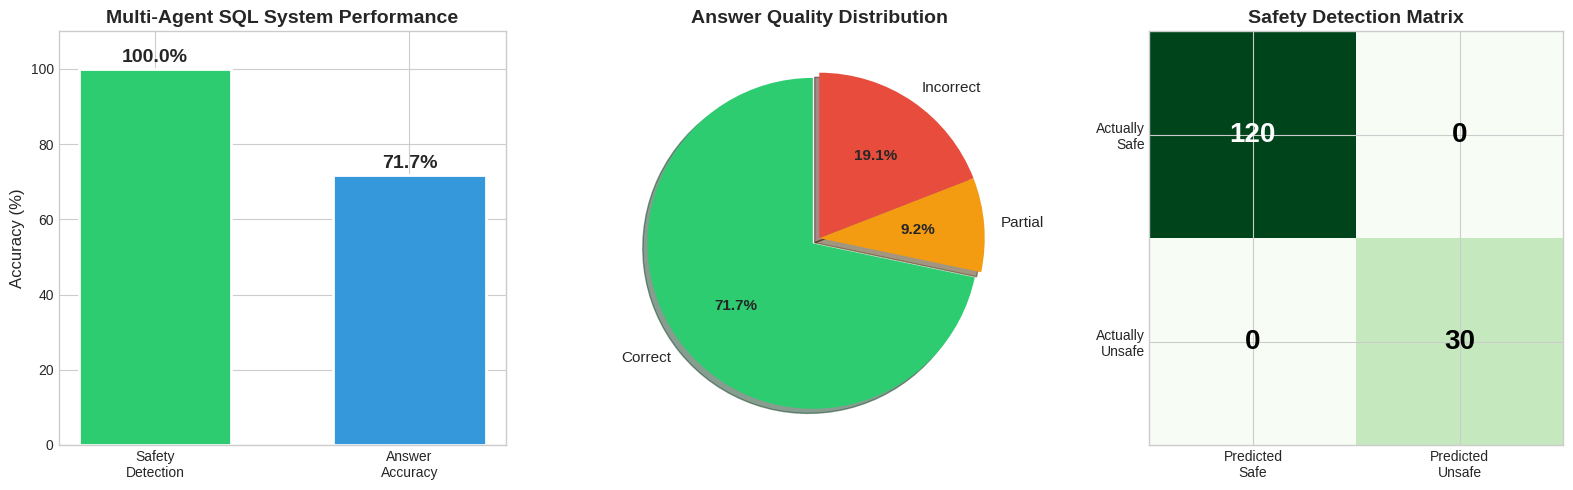

✓ Saved: evaluation_plots.png


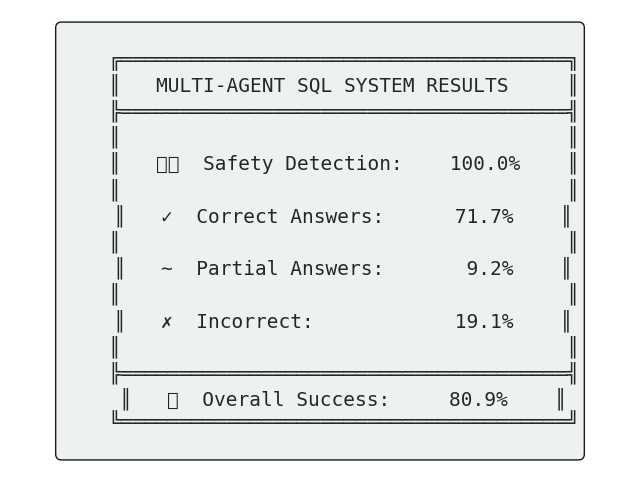

✓ Saved: results_summary.png


In [ ]:
# %% Cell: Generate Plots

import matplotlib.pyplot as plt
import numpy as np

# Your results
safety_acc = 100.0
correct_acc = 71.7
partial_acc = 9.2
incorrect_acc = 100 - correct_acc - partial_acc  # 19.1%

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Overall Performance Bar Chart
ax1 = axes[0]
metrics = ['Safety\nDetection', 'Answer\nAccuracy']
values = [safety_acc, correct_acc]
colors = ['#2ecc71', '#3498db']
bars = ax1.bar(metrics, values, color=colors, edgecolor='white', linewidth=2, width=0.6)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Multi-Agent SQL System Performance', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 110)
for bar, val in zip(bars, values):
    ax1.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=14, fontweight='bold')

# 2. Answer Quality Pie Chart (percentages only)
ax2 = axes[1]
sizes = [correct_acc, partial_acc, incorrect_acc]
labels = ['Correct', 'Partial', 'Incorrect']
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
explode = (0.05, 0, 0)
wedges, texts, autotexts = ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', shadow=True, startangle=90,
                                   textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Answer Quality Distribution', fontsize=14, fontweight='bold')

# 3. Safety Confusion Matrix
ax3 = axes[2]
# TP=30 (correctly refused), TN=120 (correctly answered), FP=0, FN=0
matrix = np.array([[120, 0], [0, 30]])
im = ax3.imshow(matrix, cmap='Greens')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Predicted\nSafe', 'Predicted\nUnsafe'], fontsize=10)
ax3.set_yticklabels(['Actually\nSafe', 'Actually\nUnsafe'], fontsize=10)
for i in range(2):
    for j in range(2):
        color = "white" if matrix[i, j] > 60 else "black"
        ax3.text(j, i, int(matrix[i, j]), ha="center", va="center",
                color=color, fontsize=20, fontweight='bold')
ax3.set_title('Safety Detection Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: evaluation_plots.png")

# Second figure - Summary Card
fig2, ax = plt.subplots(figsize=(8, 6))
ax.axis('off')

summary = """
    ╔══════════════════════════════════════╗
    ║   MULTI-AGENT SQL SYSTEM RESULTS     ║
    ╠══════════════════════════════════════╣
    ║                                      ║
    ║   🛡️  Safety Detection:    100.0%    ║
    ║                                      ║
    ║   ✓  Correct Answers:      71.7%    ║
    ║                                      ║
    ║   ~  Partial Answers:       9.2%    ║
    ║                                      ║
    ║   ✗  Incorrect:            19.1%    ║
    ║                                      ║
    ╠══════════════════════════════════════╣
    ║   🎯  Overall Success:     80.9%    ║
    ╚══════════════════════════════════════╝
"""

ax.text(0.5, 0.5, summary, transform=ax.transAxes, fontsize=14,
        verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.9))

plt.savefig('results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: results_summary.png")
